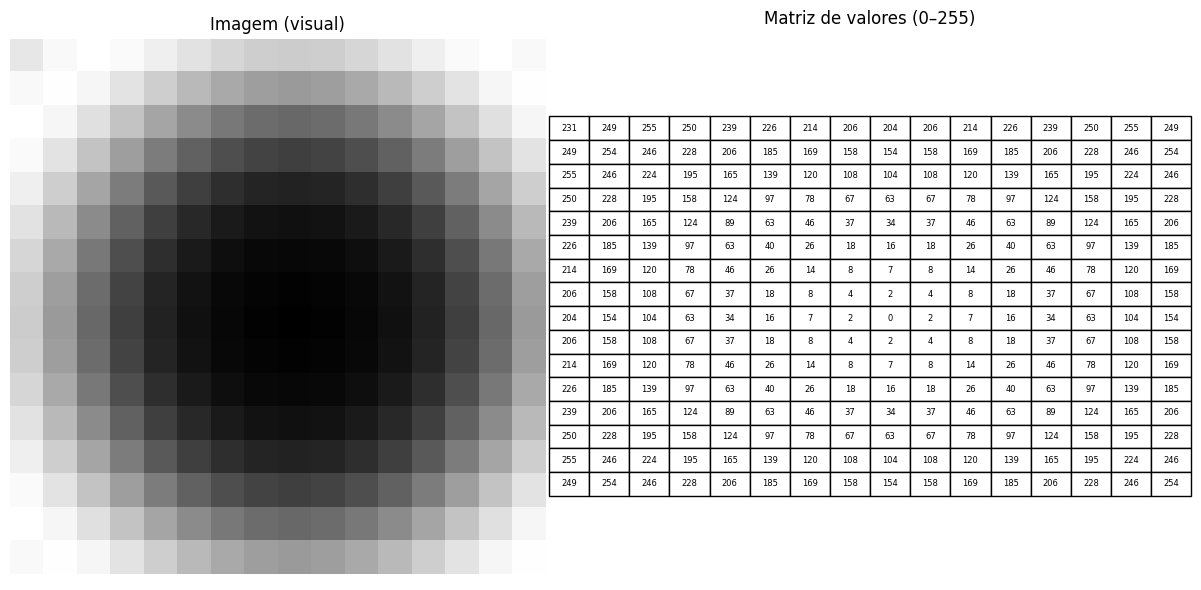

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Tamanho da imagem
size = 16

# Criar grade de coordenadas
x = np.arange(size)
y = np.arange(size)
xx, yy = np.meshgrid(x, y)

# Centro e raio
cx, cy = size // 2, size // 2
raio = 10

# Distância ao centro
dist = np.sqrt((xx - cx)**2 + (yy - cy)**2)

# Transição suave (gaussiana)
sigma = 3
img = np.exp(-((dist - raio)**2) / (2 * sigma**2))

# Normalizar para 0–255
img = (img / img.max()) * 255
img = img.astype(np.uint8)

# Criar os plots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: imagem
axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Imagem (visual)")
axes[0].axis('off')

# Plot 2: matriz de números (sem imagem)
axes[1].axis('off')
axes[1].set_title("Matriz de valores (0–255)")

# Criar tabela com os valores
tabela = axes[1].table(cellText=img,
                       loc='center',
                       cellLoc='center')

# Ajustar tamanho da tabela
tabela.auto_set_font_size(False)
tabela.set_fontsize(6)
tabela.scale(1.2, 1.2)

plt.tight_layout()
plt.show()

In [ ]:
# Plot 2: matriz de números (sem imagem)
axes[1].axis('off')
axes[1].set_title("Matriz de valores (0–255)")

# Criar tabela com os valores
tabela = axes[1].table(cellText=img,
                       loc='center',
                       cellLoc='center')

# Ajustar tamanho da tabela
tabela.auto_set_font_size(False)
tabela.set_fontsize(6)
tabela.scale(1.2, 1.2)

plt.tight_layout()
plt.show()

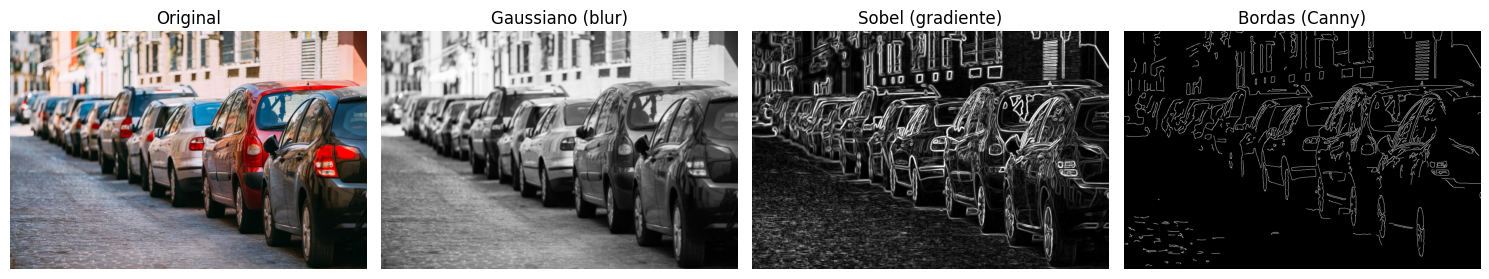

In [15]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Caminho da imagem
caminho = "resources/imgs/carros.jpg"  # <-- troque aqui

# Ler imagem (OpenCV lê em BGR)
img = cv2.imread(caminho)

# Converter para RGB (para plot)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Converter para escala de cinza
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 1. Filtro Gaussiano (blur)
gauss = cv2.GaussianBlur(gray, (5, 5), 0)

# 2. Sobel (gradiente em x e y)
sobel_x = cv2.Sobel(gauss, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gauss, cv2.CV_64F, 0, 1, ksize=3)

# Magnitude do gradiente
sobel = np.sqrt(sobel_x**2 + sobel_y**2)
sobel = np.uint8(np.clip(sobel, 0, 255))

# 3. Detecção de bordas (Canny)
edges = cv2.Canny(gauss, 100, 200)

# Plot
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

# Imagem original
axes[0].imshow(img_rgb)
axes[0].set_title("Original")
axes[0].axis('off')


# Gaussiano
axes[1].imshow(gauss, cmap='gray')
axes[1].set_title("Gaussiano (blur)")
axes[1].axis('off')

# Sobel
axes[2].imshow(sobel, cmap='gray')
axes[2].set_title("Sobel (gradiente)")
axes[2].axis('off')

# Canny
axes[3].imshow(edges, cmap='gray')
axes[3].set_title("Bordas (Canny)")
axes[3].axis('off')

plt.tight_layout()
plt.show()